# THOR on the EuroCrops pilot chips, the embedding workflow

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**What this is.** THOR v1 large on the pilot chips, run through TerraTorch's second workflow exactly as [`eurocrops_terramind_pilot_embeddings.ipynb`](eurocrops_terramind_pilot_embeddings.ipynb) runs TerraMind. The first workflow keeps the frozen encoder inside the training loop, so every epoch of every fit re-encodes every chip although the encoder never changes; for THOR those end-to-end fits are run by `scripts/seg/train.py` with the configuration below, into `results/seg/thor_v1_large_ee_pilot/`, and are the reference of section 7. Here the encoder runs **once per chip**, through TerraTorch's `EmbeddingGenerationTask`, and only the trainable part of the model is trained from the stored features.

```
end-to-end   chip ──► frozen encoder ──► frozen necks ──► trainable necks ──► decoder ──► head      every step
two-stage    chip ──► frozen encoder ──► frozen necks ──► disk                                     once per chip
                                                   disk ──► trainable necks ──► decoder ──► head    every step
```

**The two train the same model.** The encoder is frozen, so its output for a given input is fixed, and caching it removes only the repetition. This notebook does not take that on trust: section 4 compares the cached features with the ones the encoder produces inside the training loop, and section 7 compares the metrics of the two workflows over several seeds.

**Kernel.** Python 3.11 (gfm4agri). The pilot chips must exist, see `scripts/data/build_pilot_chips.py`. The machinery lives in `src/gfm4agri/benchmark/cached.py`; this notebook calls it and shows what it does.

**THOR is not part of TerraTorch.** It comes through its own extension, `thor_terratorch_ext`, which `scripts/env/install_thor.sh` installs outside the Poetry lock, and the backbone registry imports it only when a THOR entry is built. The first forward pass in a process takes about a minute, because THOR compiles its attention-bias function with `torch.compile`.

**Another backbone.** Point `CONFIG` below at a copy of `thor_v1_large_ee_pilot.yaml` with `model.backbone: thor_v1_base` and everything follows.

In [1]:
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO / "src"))

from gfm4agri.benchmark.backbones import get_backbone
from gfm4agri.benchmark.cached import (EMB_SUFFIX, IDENTITY, VARIANTS, CachedFeatureDataModule,
                                       apply_d4, embedding_model_args, fit_cached,
                                       generate_embeddings, split_at_cache_point, variant_name)
from gfm4agri.benchmark.segmentation import build_task
from gfm4agri.benchmark.segmentation_data import EuroCropsSegDataModule

CONFIG = REPO / 'configs/seg/thor_v1_large_ee_pilot.yaml'
cfg = yaml.safe_load(CONFIG.read_text())
BACKBONE = cfg["model"]["backbone"]
ROOT = REPO / cfg["data"]["root"]
CACHE = REPO / "data" / "embeddings" / BACKBONE / ROOT.name     # stage 1 output
E2E = REPO / "results" / "seg" / cfg["run_name"]                # end-to-end runs, the reference
TWO = REPO / "results" / "seg_cached" / cfg["run_name"]         # the runs of this notebook
BUDGETS = [5, 20, 100]                                          # per cent of each class's parcels
SEEDS = [0, 1, 2]
REBUILD_CACHE = False                                           # True re-encodes an existing cache
print(BACKBONE, "|", ROOT.relative_to(REPO), "->", CACHE.relative_to(REPO))

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


thor_v1_large | data/eurocrops_chips/EE_2021_pilot -> data/embeddings/thor_v1_large/EE_2021_pilot


## 1. The cache point

The end-to-end model is a chain of modules, and the chain splits in two at the first one with trainable parameters. Everything before that point is frozen and deterministic, so its output can be computed once and stored. Everything after it is what the label budget trains.

In [2]:
dm = EuroCropsSegDataModule(ROOT, BACKBONE, normalisation=cfg["data"]["normalisation"],
                            batch_size=1, num_workers=0, augment=False)
frozen, trainable = split_at_cache_point(get_backbone(BACKBONE).model_args(dm.bands, dm.n_timesteps))
print("stage 1, run once per chip :  encoder ->", " -> ".join(n["name"] for n in frozen))
print("stage 2, trained per budget:", " -> ".join(n["name"] for n in trainable), "-> decoder -> head")
embedding_model_args(BACKBONE, dm.bands, dm.n_timesteps)

INFO:thor.models.patch_timm:Patching timm Attention and Block to use Alibi...


INFO:thor.models.patch_timm:Using normal attention for timm Attention


stage 1, run once per chip :  encoder -> SelectIndices
stage 2, trained per budget: ChannelBottleneck -> LearnedInterpolateToPyramidal -> decoder -> head


{'backbone': 'thor_v1_large',
 'backbone_pretrained': True,
 'backbone_model_bands': ['BLUE',
  'GREEN',
  'RED',
  'NIR_BROAD',
  'RED_EDGE_1',
  'RED_EDGE_2',
  'RED_EDGE_3',
  'NIR_NARROW',
  'SWIR_1',
  'SWIR_2'],
 'backbone_ground_cover': 2240,
 'backbone_patch_sizes': {'BLUE': 16,
  'GREEN': 16,
  'RED': 16,
  'NIR_BROAD': 16,
  'RED_EDGE_1': 8,
  'RED_EDGE_2': 8,
  'RED_EDGE_3': 8,
  'NIR_NARROW': 8,
  'SWIR_1': 8,
  'SWIR_2': 8},
 'backbone_merge_method': 'concat',
 'backbone_use_temporal': True,
 'backbone_temporal_pooling': 'concat',
 'backbone_temporal_n_timestamps': 12,
 'necks': [{'name': 'SelectIndices', 'indices': [5, 11, 17, 23]}]}

THOR is a single-date model, so TerraTorch's temporal wrapper runs it once per month, as for TerraMind. Within a month it tokenises each spectral group on its own: the four 10 m bands (B02, B03, B04, B08) at 16 px patches and the six 20 m bands (B05, B06, B07, B8A, B11, B12) at 8 px, so both groups give a 14 x 14 grid of 160 m tokens and attend to each other in one sequence of 392. B01 and B09, THOR's 60 m group, do not tile the 2,240 m chip and are left out. Its TerraTorch wrapper concatenates the two groups' token maps, as the THOR authors do for dense tasks, and the temporal wrapper the twelve months: 12 x 2 x 1,024 = 24,576 channels per layer for the large variant. So what is stored for every chip is, for each of the four selected encoder layers, a `(channels, 14, 14)` map: one vector per 16 x 16 pixel patch, with the months stacked on the channel axis.

## 2. Stage 1: encode every chip once

`generate_embeddings` runs TerraTorch's `EmbeddingGenerationTask` over the chips with the frozen head of the model from section 1, under the same autocast precision as the end-to-end fit, so the stored features are the ones the decoder would have seen.

**Augmentation has to be encoded, not applied afterwards.** The end-to-end fit draws one of the eight D4 symmetries of each training chip at every step. A ViT is not equivariant to rotation, so the features of a rotated chip are not the rotated features of the chip, and section 5 measures by how much. Training chips are therefore encoded in all eight variants; validation chips once, unrotated. The features are stored as float16 arrays, one file per chip, variant and layer, in TerraTorch's folder layout.

In [3]:
if REBUILD_CACHE or not (CACHE / "cache.json").exists():
    cache = generate_embeddings(BACKBONE, ROOT, CACHE, normalisation=cfg["data"]["normalisation"],
                                batch_size=4, num_workers=4, precision=cfg["trainer"]["precision"])
else:
    cache = json.loads((CACHE / "cache.json").read_text())
per = cache["encode_seconds"] / cache["chip_encodings"]
print(f"{cache['chip_encodings']} chip encodings in {cache['encode_seconds']:.0f} s ({per:.2f} s each, model loading included)")
print(f"{cache['bytes'] / 1e6:.0f} MB on disk, {cache['bytes'] / 1e6 / cache['chip_encodings']:.1f} MB per chip and variant, {cache['dtype']}")
print(f"layers {cache['encoder_layers']} -> channels {cache['channel_list']}, feature map {cache['feature_size']}")
pd.DataFrame(cache["runs"])

Missing flexivit_patch_size_seqs entries for channels: ['S1:EW-HH', 'S1:EW-HV', 'S1:EW-VH', 'S1:EW-VV', 'S1:IW-HH', 'S1:IW-HV', 'S1:IW-VH', 'S1:IW-VV', 'S2:CoastAerosal', 'S2:WaterVapor', 'S3:Oa01_reflectance', 'S3:Oa02_reflectance', 'S3:Oa03_reflectance', 'S3:Oa04_reflectance', 'S3:Oa05_reflectance', 'S3:Oa06_reflectance', 'S3:Oa07_reflectance', 'S3:Oa08_reflectance', 'S3:Oa09_reflectance', 'S3:Oa10_reflectance', 'S3:Oa11_reflectance', 'S3:Oa12_reflectance', 'S3:Oa13_reflectance', 'S3:Oa14_reflectance', 'S3:Oa15_reflectance', 'S3:Oa16_reflectance', 'S3:Oa17_reflectance', 'S3:Oa18_reflectance', 'S3:Oa19_reflectance', 'S3:Oa20_reflectance', 'S3:Oa21_reflectance', 'S3:S1_reflectance_an', 'S3:S2_reflectance_an', 'S3:S3_reflectance_an', 'S3:S4_reflectance_an', 'S3:S5_reflectance_an', 'S3:S6_reflectance_an', 'S3:S7_BT_in', 'S3:S8_BT_in', 'S3:S9_BT_in'],


[stage 1] thor_v1_large k0: encoding 12 chips


/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: e

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/lightning/pytorch/loops/prediction_loop.py:257: predict returned None if it was on purpose, ignore this warning...


...

[stage 1] thor_v1_large k3f: encoding 8 chips


/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: e

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


68 chip encodings in 130 s (1.91 s each, model loading included)
2620 MB on disk, 38.5 MB per chip and variant, float16
layers [5, 11, 17, 23] -> channels [24576, 24576, 24576, 24576], feature map [14, 14]


,variant,splits,chips,reused,seconds
0,k0,"[train, val]",12,0,24.8
1,k0f,[train],8,0,14.1
2,k1,[train],8,0,14.2
3,k1f,[train],8,0,15.6
4,k2,[train],8,0,15.9
5,k2f,[train],8,0,14.8
6,k3,[train],8,0,15.1
7,k3f,[train],8,0,15.4


## 3. What the stored features look like

One training chip, three of its eight variants. The left column is the chip as the encoder saw it, true colour for June. The right column is the deepest cached layer, reduced to three principal components shown as colour, one pixel per 16 x 16 patch. Parcels that the chip shows in one colour tend to share a colour in the feature map, and the map turns with the chip.

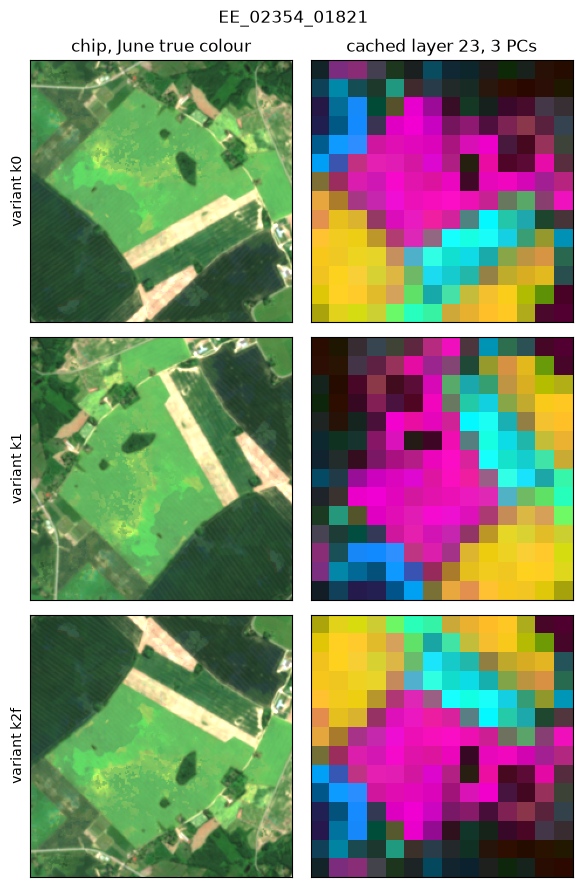

In [4]:
import rasterio

tids = (ROOT / "training_data.txt").read_text().split()
CHIP = tids[0]
with rasterio.open(ROOT / "training_chips" / f"{CHIP}_merged.tif") as src:
    june = src.read().reshape(12, 12, 224, 224)[5][[3, 2, 1]].transpose(1, 2, 0).astype(float)
rgb = np.clip(june / np.percentile(june, 98), 0, 1)
last = len(cache["channel_list"]) - 1
feats = {v: np.load(CACHE / v / f"layer_{last:02d}" / f"{CHIP}{EMB_SUFFIX}").astype(np.float32)
         for v in ("k0", "k1", "k2f")}
flat = np.concatenate([f.reshape(f.shape[0], -1).T for f in feats.values()])
mean = flat.mean(0)
_, _, vt = np.linalg.svd(flat - mean, full_matrices=False)
lo, hi = np.percentile((flat - mean) @ vt[:3].T, [2, 98], axis=0)

fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for row, (v, f) in enumerate(feats.items()):
    k, flip = int(v[1]), v.endswith("f")
    pcs = ((f.reshape(f.shape[0], -1).T - mean) @ vt[:3].T).reshape(*f.shape[1:], 3)
    axes[row, 0].imshow(apply_d4(rgb, k, flip))
    axes[row, 1].imshow(np.clip((pcs - lo) / (hi - lo), 0, 1), interpolation="nearest")
    axes[row, 0].set_ylabel(f"variant {v}")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_title("chip, June true colour"); axes[0, 1].set_title(f"cached layer {cache['encoder_layers'][last]}, 3 PCs")
fig.suptitle(CHIP); plt.tight_layout(); plt.show()

## 4. Are the cached features the ones the training loop sees?

For one validation chip, the features are computed the way the end-to-end fit computes them, through the full model's encoder and frozen necks, and compared with the stored file. The measure is the relative error, the size of the difference over the size of the features, together with the correlation. For scale, the last line compares the stored chip with a *different* chip, which is what a genuine mismatch looks like.

In [5]:
AUTOCAST = "16" in cfg["trainer"]["precision"]
dm.setup("fit")
vids = [Path(f).name[: -len("_merged.tif")] for f in dm.val_dataset.image_files]

def in_loop(i):
    item = dm.val_dataset[i]
    b = dm.aug({k: (v[None] if torch.is_tensor(v) else [v]) for k, v in item.items()})
    x = dm.split_modalities(b["image"])
    x = x.cuda() if torch.is_tensor(x) else {k: v.cuda() for k, v in x.items()}
    kw = {k: b[k].cuda() for k in ("temporal_coords", "location_coords") if k in b}
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=AUTOCAST):
        f = full.neck[: len(frozen)](full.encoder(x, **kw), image_size=(224, 224))
    return f, x

full = build_task(BACKBONE, num_classes=len(dm.class_names), class_names=dm.class_names,
                  bands=dm.bands, n_timesteps=dm.n_timesteps).model.cuda().eval()
feats_loop, x = in_loop(0)
rows = []
for layer, f in enumerate(feats_loop):
    a = f[0].float().cpu().numpy()
    c = np.load(CACHE / "k0" / f"layer_{layer:02d}" / f"{vids[0]}{EMB_SUFFIX}").astype(np.float32)
    rows.append({"layer": cache["encoder_layers"][layer], "shape": a.shape,
                 "relative error": np.linalg.norm(a - c) / np.linalg.norm(a),
                 "correlation": np.corrcoef(a.ravel(), c.ravel())[0, 1]})
other = np.load(CACHE / "k0" / f"layer_{len(feats_loop) - 1:02d}" / f"{vids[1]}{EMB_SUFFIX}").astype(np.float32)
a = feats_loop[-1][0].float().cpu().numpy()
print(f"reference, a different chip: relative error {np.linalg.norm(a - other) / np.linalg.norm(a):.2e}, "
      f"correlation {np.corrcoef(a.ravel(), other.ravel())[0, 1]:.4f}")
pd.DataFrame(rows).style.format({"relative error": "{:.2e}", "correlation": "{:.7f}"})

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
Missing flexivit_patch_size_seqs entries for channels: ['S1:EW-HH', 'S1:EW-HV', 'S1:EW-VH', 'S1:EW-VV', 'S1:IW-HH', 'S1:IW-HV', 'S1:IW-VH', 'S1:IW-VV', 'S2:CoastAer

reference, a different chip: relative error 8.78e-01, correlation 0.6127


,layer,shape,relative error,correlation
0,5,"(24576, 14, 14)",9.57e-04,0.9999995
1,11,"(24576, 14, 14)",1.22e-03,0.9999992
2,17,"(24576, 14, 14)",1.49e-03,0.9999989
3,23,"(24576, 14, 14)",1.55e-03,0.9999988


In [6]:
# Encoder cost per chip, measured here for section 8: forward passes over the four validation
# chips as one batch, under the fit's autocast.
items = [dm.val_dataset[i] for i in range(len(vids))]
b = dm.aug({k: (torch.stack([it[k] for it in items]) if torch.is_tensor(items[0][k]) else [it[k] for it in items])
            for k in items[0]})
xb = dm.split_modalities(b["image"])
xb = xb.cuda() if torch.is_tensor(xb) else {k: v.cuda() for k, v in xb.items()}
kwb = {k: b[k].cuda() for k in ("temporal_coords", "location_coords") if k in b}
def encode():
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=AUTOCAST):
        return full.neck[: len(frozen)](full.encoder(xb, **kwb), image_size=(224, 224))
for _ in range(2):
    encode()
torch.cuda.synchronize(); t0 = time.time()
for _ in range(5):
    encode()
torch.cuda.synchronize()
ENC_S_PER_CHIP = (time.time() - t0) / 5 / len(items)
print(f"encoder and frozen necks: {ENC_S_PER_CHIP * 1000:.0f} ms per chip")

encoder and frozen necks: 103 ms per chip


The cached features agree with the in-loop ones to the precision the encoder runs at: under 16-bit autocast a relative error of one to one and a half parts in a thousand, growing slightly with depth, at a correlation above 0.99999 in every layer. Against that, a different chip differs by nearly its own size.

## 5. Why every rotation is encoded

If the encoder were equivariant to rotation, the features of a rotated chip would equal the rotated features of the chip, and storing one variant would be enough. The cell below tests that on the cache itself: for every variant, the stored features are compared with the identity features rotated the same way.

In [7]:
rows = []
for k, flip in VARIANTS:
    v = variant_name(k, flip)
    stored = np.load(CACHE / v / f"layer_{last:02d}" / f"{CHIP}{EMB_SUFFIX}").astype(np.float32)
    rotated = apply_d4(feats["k0"].transpose(1, 2, 0), k, flip).transpose(2, 0, 1)
    rows.append({"variant": v, "relative error": np.linalg.norm(stored - rotated) / np.linalg.norm(stored),
                 "correlation": np.corrcoef(stored.ravel(), rotated.ravel())[0, 1]})
pd.DataFrame(rows).style.format({"relative error": "{:.3f}", "correlation": "{:.4f}"})

,variant,relative error,correlation
0,k0,0.000,1.0000
1,k0f,0.323,0.9478
2,k1,0.404,0.9181
3,k1f,0.378,0.9285
4,k2,0.425,0.9098
5,k2f,0.370,0.9317
6,k3,0.404,0.9184
7,k3f,0.355,0.9369


Apart from the identity, which matches by construction, rotating the features is a poor stand-in for encoding the rotated chip, although a better one than for TerraMind or Prithvi, whose pilot caches correlate at 0.81 to 0.92 under the same test. THOR has no positional embedding: its ALiBi bias depends only on the distance between two tokens, which a rotation of the chip preserves. What does not rotate is the patch embedding, a learned kernel per band that sees the pixels of each patch in one orientation, and every token passes through it. A relative error of a third to two fifths is still far from the precision of section 4, so training on rotated features would show the decoder inputs it never meets at test time. Every rotation is therefore encoded here as well, at eight times the stage 1 cost for the training chips.

## 6. Stage 2: train the decoder from the cache

`fit_cached` builds the end-to-end model, keeps exactly its trainable modules, and trains them through TerraTorch's `SemanticSegmentationTask` with the configuration of the end-to-end run: the same label budget draw, optimiser, learning rate, weight decay, dropout, loss, precision, number of epochs, effective batch and validation checkpointing. It writes `results.json` with the same fields as `scripts/seg/train.py`, plus `workflow` and a summary of the cache it read. Fits that already exist are read back rather than repeated.

In [8]:
full = None                     # the end-to-end model of section 4 is not needed any more
torch.cuda.empty_cache()

def run(pct, seed):
    out = TWO / f"P{pct:g}_draw0_seed{seed}" / "results.json"
    if out.exists():
        return json.loads(out.read_text())
    return fit_cached(dict(cfg, seed=seed), CACHE, pct=pct, num_workers=4)

two = {(p, s): run(p, s) for s in SEEDS for p in BUDGETS}
t = two[(BUDGETS[-1], SEEDS[0])]
print(f"trainable parameters: {t['params']['trainable_total']:,}; fit at {BUDGETS[-1]} %: {t['fit_seconds']:.0f} s")

Seed set to 0


/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True


INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


...

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /data/private/THESIS - ExplainedGMF4Agri/results/seg_cached/thor_v1_large_ee_pilot/P100_draw0_seed2/checkpoints/best-loss.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /data/private/THESIS - ExplainedGMF4Agri/results/seg_cached/thor_v1_large_ee_pilot/P100_draw0_seed2/checkpoints/best-loss.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                      Test metric                       ┃                      DataLoader 0                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                     test/Accuracy                      │                  0.27287501096725464                   │
│                   test/Boundary_mIoU                   │                   0.0384170338511467                   │
│          test/Class_Accuracy_alfalfa_lucerne           │                          0.0                           │
│               test/Class_Accuracy_beans                │                          0.0                           │
│             test/Class_Accuracy_buckwheat              │                   0.4032258093357086                   │
│               test/Class_Accuracy_clover               │                   0.7777946591377258                   │
│          test/Class_Accuracy_fresh_vegetables          │                          0.0                           │
│      test/Class_Accuracy_grain_maize_corn_popcorn      │                  0.061650991439819336                  │
│ test/Class_Accuracy_legumes_dried_pulses_protein_crops │                          0.0                           │
│      test/Class_Accuracy_legumes_harvested_green       │                  0.27219194173812866                   │
│                test/Class_Accuracy_oats                │                   0.3009929060935974                   │
│          test/Class_Accuracy_orchards_fruits           │                          0.0                           │
│   test/Class_Accuracy_pasture_meadow_grassland_grass   │                   0.7069506645202637                   │
│                test/Class_Accuracy_peas                │                  0.46145865321159363                   │
│              test/Class_Accuracy_potatoes              │                          0.0                           │
│                test/Class_Accuracy_rye                 │                  0.056239016354084015                  │
│           test/Class_Accuracy_spring_barley            │                   0.5549288392066956                   │
│      test/Class_Accuracy_spring_common_soft_wheat      │                  0.004604404792189598                  │
│        test/Class_Accuracy_spring_rapeseed_rape        │                          0.0                           │
│           test/Class_Accuracy_winter_barley            │                          0.0                           │
│      test/Class_Accuracy_winter_common_soft_wheat      │                   0.869623601436615                    │
│        test/Class_Accuracy_winter_rapeseed_rape        │                   0.987838864326477                    │
│                     test/F1_Score                      │                  0.23938614130020142                   │
│                test/IoU_alfalfa_lucerne                │                          0.0                           │
│                     test/IoU_beans                     │                          0.0                           │
│                   test/IoU_buckwheat                   │                  0.10196514427661896                   │
│                    test/IoU_clover                     │                   0.5343782901763916                   │
│               test/IoU_fresh_vegetables                │                          0.0                           │
│           test/IoU_grain_maize_corn_popcorn            │                  0.04495808854699135                   │
│      test/IoU_legumes_dried_pulses_protein_crops       │                          0.0                           │
│            test/IoU_legumes_harvested_green            │                  0.18299120664596558                   │
│                     test/IoU_oats                     

trainable parameters: 91,030,228; fit at 100 %: 282 s


## 7. Are the metrics the same?

The two workflows compute their metrics identically: the same TerraTorch task, the same 47 metrics, the same `ignore_index`, the same test chips. Whether they reach the same *values* can only be judged against the variation of the end-to-end runs themselves: repeating an identical end-to-end configuration with another seed moves Macro-F1 by a few hundredths on these twelve chips, because the decoder is initialised and fed in a different random order and the rare classes flip on and off. Two workflows that train the same model should therefore overlap in their spread over seeds, not agree to the third decimal.

The label draw is fixed at draw 0 throughout, so the seeds vary the training only.

**Augmentation in both workflows.** Both data pipelines draw the D4 symmetry from PyTorch's generator. That is the fix for a fault this comparison found in the TerraMind and Prithvi notebooks, where the end-to-end pipeline replayed the same few symmetries every epoch; section 7 of [`eurocrops_terramind_pilot_embeddings.ipynb`](eurocrops_terramind_pilot_embeddings.ipynb) tells it. A regression test in `tests/test_segmentation_data.py` fails on the old draw.

In [9]:
def load_e2e(pct, seed):
    f = E2E / f"P{pct:g}_draw0_seed{seed}" / "results.json"
    return json.loads(f.read_text()) if f.exists() else None

rows = []
for p in BUDGETS:
    for wf, get in (("end-to-end", lambda p, s: load_e2e(p, s)), ("two-stage", lambda p, s: two.get((p, s)))):
        for s in SEEDS:
            r = get(p, s)
            if r:
                rows.append({"K %": p, "workflow": wf, "seed": s, "Macro-F1": r["test_metrics"]["test/F1_Score"],
                             "mIoU": r["test_metrics"]["test/mIoU"], "fit s": r["fit_seconds"]})
res = pd.DataFrame(rows)
summary = res.groupby(["K %", "workflow"]).agg(
    seeds=("seed", "count"), f1_mean=("Macro-F1", "mean"), f1_min=("Macro-F1", "min"), f1_max=("Macro-F1", "max"),
    miou_mean=("mIoU", "mean"), fit_s=("fit s", "mean")).round(4)
summary

seeds  f1_mean  f1_min  f1_max  miou_mean     fit_s
K % workflow                                                       
5   end-to-end      3   0.1131  0.0922  0.1347     0.0690  383.9667
    two-stage       3   0.0884  0.0819  0.0947     0.0522  256.8333
20  end-to-end      3   0.1293  0.1104  0.1573     0.0857  374.5333
    two-stage       3   0.0917  0.0677  0.1190     0.0586  254.1667
100 end-to-end      3   0.2327  0.2312  0.2358     0.1684  565.5667
    two-stage       3   0.2305  0.2195  0.2394     0.1664  308.1333

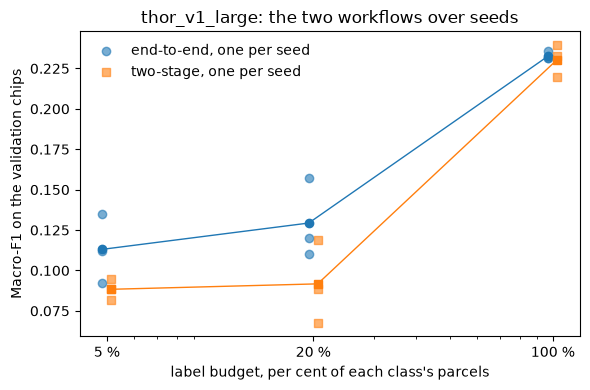

5 %: ranges overlap (end-to-end 0.092 to 0.135, n = 3; two-stage 0.082 to 0.095, n = 3)
20 %: ranges overlap (end-to-end 0.110 to 0.157, n = 3; two-stage 0.068 to 0.119, n = 3)
100 %: ranges overlap (end-to-end 0.231 to 0.236, n = 3; two-stage 0.219 to 0.239, n = 3)


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
for wf, marker, dx in (("end-to-end", "o", -0.6), ("two-stage", "s", 0.6)):
    d = res[res["workflow"] == wf]
    ax.scatter(d["K %"] * np.exp(dx / 20), d["Macro-F1"], marker=marker, alpha=0.6, label=f"{wf}, one per seed")
    m = d.groupby("K %")["Macro-F1"].mean()
    ax.plot(m.index * np.exp(dx / 20), m.values, marker=marker, linewidth=1)
ax.set_xscale("log"); ax.set_xticks(BUDGETS); ax.set_xticklabels([f"{b} %" for b in BUDGETS])
ax.set_xlabel("label budget, per cent of each class's parcels"); ax.set_ylabel("Macro-F1 on the validation chips")
ax.set_title(f"{BACKBONE}: the two workflows over seeds"); ax.legend(frameon=False); plt.tight_layout(); plt.show()

overlap = []
for p in BUDGETS:
    a, b = res[(res["K %"] == p) & (res.workflow == "end-to-end")]["Macro-F1"], res[(res["K %"] == p) & (res.workflow == "two-stage")]["Macro-F1"]
    if len(a) and len(b):
        overlap.append(f"{p} %: ranges {'overlap' if max(a.min(), b.min()) <= min(a.max(), b.max()) else 'do NOT overlap'} "
                       f"(end-to-end {a.min():.3f} to {a.max():.3f}, n = {len(a)}; two-stage {b.min():.3f} to {b.max():.3f}, n = {len(b)})")
print("\n".join(overlap))

Read the table and the plot together. Where the two ranges overlap, the difference between the workflows is inside the variation either one shows on its own, and the two cannot be told apart. A range built from a single end-to-end seed is a point, so overlap with it is a weak test; three or more seeds on each side are what make the comparison mean something.

**For THOR** the ranges overlap at every budget, and at 100 % the two workflows agree within a hundredth. At 5 % and 20 % the two-stage mean is lower by two to four hundredths, and at 5 % the ranges only just touch. Differences of that size, in either direction, also appear in the TerraMind and Prithvi notebooks, where Prithvi's two-stage fits score higher at 20 %, so the pilot cannot tell them from seed variation. Both low budgets falling on the same side is the thing to watch when THOR is run on the full split, where the test set is large enough to resolve it.

## 8. What it costs, and what it would cost for Estonia

Stage 1 is paid once per chip, variant and backbone. Stage 2 is paid per fit, and the Phase 1 protocol calls for many fits: every label budget, several draws of every budget, every backbone. The end-to-end workflow pays the encoder inside every one of them.

The pilot's own fit times are no guide to that. Twelve chips cannot amortise the fixed cost of a fit, so dividing a pilot fit time by its chips attributes model loading, validation and checkpointing to each chip. The cell below therefore measures the three per-chip costs that scale with the data: encoding a chip, reading its cached features, and one training step of the decoder. It extrapolates from those, charging each workflow for everything it does per chip and epoch: the end-to-end fit **loads and augments the raw chip, encodes it and trains**; the two-stage fit **reads the cached features and trains**. Loading runs in DataLoader workers alongside the GPU in both, so both figures are upper bounds in the same way. Timings are indicative only, since the GPU is shared with another container that at times slows every kernel, and reads from the network file system vary.

In [11]:
from gfm4agri.benchmark.cached import build_cached_model

# the end-to-end fit loads and augments the raw chip every epoch
raw = EuroCropsSegDataModule(ROOT, BACKBONE, normalisation=cfg["data"]["normalisation"],
                             batch_size=1, num_workers=0, augment=True)
raw.setup("fit")
t0 = time.time()
for i in range(16):
    raw.train_dataset[i % len(raw.train_dataset)]
LOAD_S_PER_CHIP = (time.time() - t0) / 16

# the two-stage fit reads the cached features instead
cdm = CachedFeatureDataModule(ROOT, CACHE, batch_size=4, num_workers=0)
cdm.setup("fit")
t0 = time.time()
for i in range(16):
    cdm.train_dataset[i % len(cdm.train_dataset)]
READ_S_PER_CHIP = (time.time() - t0) / 16

m = build_cached_model(BACKBONE, num_classes=len(cdm.class_names), class_names=cdm.class_names,
                       bands=dm.bands, n_timesteps=dm.n_timesteps, channel_list=cache["channel_list"]).cuda()
opt, scaler = torch.optim.AdamW(m.parameters(), lr=1e-4), torch.amp.GradScaler()
batch = next(iter(cdm.train_dataloader()))
xs, ys = batch["image"].cuda(), batch["mask"].cuda()
def step():
    with torch.autocast("cuda", dtype=torch.float16, enabled=AUTOCAST):
        loss = torch.nn.functional.cross_entropy(m(xs).output, ys, ignore_index=cdm.ignore_index)
    scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); opt.zero_grad()
for _ in range(3):
    step()
torch.cuda.synchronize(); t0 = time.time()
for _ in range(20):
    step()
torch.cuda.synchronize()
DEC_S_PER_CHIP = (time.time() - t0) / 20 / xs.shape[0]
del m, opt; torch.cuda.empty_cache()

per_chip = pd.DataFrame({"seconds per chip": {
    "load and augment the raw chip (end-to-end)": LOAD_S_PER_CHIP,
    "encode, encoder and frozen necks (end-to-end)": ENC_S_PER_CHIP,
    "read cached features (two-stage)": READ_S_PER_CHIP,
    "decoder training step (both)": DEC_S_PER_CHIP}})
per_chip.style.format("{:.3f}")

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(


/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/torch/nn/functional.py:3504: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


,seconds per chip
load and augment the raw chip (end-to-end),0.152
"encode, encoder and frozen necks (end-to-end)",0.103
read cached features (two-stage),0.076
decoder training step (both),0.015


In [12]:
# Full Estonia under the 4 x 4-chip block split blocks4_buf1600_seed0: 4,898 training chips,
# 769 validation and 1,475 test chips; every training chip in all eight D4 variants.
EE_TRAIN, EE_VAL, EE_TEST = 4898, 769, 1475
EPOCHS = cfg["trainer"]["max_epochs"]
chip_epochs = (EE_TRAIN + EE_VAL) * EPOCHS
encodings = EE_TRAIN * len(cache["train_variants"]) + EE_VAL + EE_TEST
mb = cache["bytes"] / 1e6 / cache["chip_encodings"]

stage1_h = encodings * (LOAD_S_PER_CHIP + ENC_S_PER_CHIP) / 3600   # every encoding loads its chip
two_fit_h = chip_epochs * (READ_S_PER_CHIP + DEC_S_PER_CHIP) / 3600
e2e_fit_h = chip_epochs * (LOAD_S_PER_CHIP + ENC_S_PER_CHIP + DEC_S_PER_CHIP) / 3600
print(f"stage 1, once: {encodings:,} encodings, {stage1_h:.1f} h, {encodings * mb / 1e3:.0f} GB")
print(f"one fit of {EPOCHS} epochs: two-stage {two_fit_h:.1f} h, end-to-end {e2e_fit_h:.1f} h")
saving = e2e_fit_h - two_fit_h
print(f"per fit, two-stage {'saves' if saving > 0 else 'costs'} {abs(saving):.1f} h; stage 1 pays for itself after "
      + (f"{stage1_h / saving:.1f} fits\n" if saving > 0 else "no number of fits: reading the cache costs more than encoding\n"))
rows = []
for fits in (3, 15, 50, 150):
    rows.append({"fits": fits, "end-to-end h": fits * e2e_fit_h, "two-stage h": stage1_h + fits * two_fit_h})
pd.DataFrame(rows).set_index("fits").style.format("{:.0f}")

stage 1, once: 41,428 encodings, 2.9 h, 1596 GB
one fit of 40 epochs: two-stage 5.7 h, end-to-end 17.0 h
per fit, two-stage saves 11.3 h; stage 1 pays for itself after 0.3 fits



,end-to-end h,two-stage h
fits,,
3,51,20
15,256,89
50,852,290
150,2557,865


## 9. What this establishes

* The cached features are the features the end-to-end fit trains on, to the precision the encoder runs at (section 4).
* Augmentation survives the move only because every rotation is encoded; rotating stored features would not reproduce it (section 5).
* The trainable model, its parameter count, the label draw, the optimisation and the metrics are identical by construction (section 6), and section 7 shows whether the resulting scores fall inside each other's seed spread.
* The two-stage workflow removes loading the raw chip and running the encoder from every fit, and replaces both with reading the cached features back, plus a one-time encoding and the disk to hold it (section 8). For THOR large the encoder is about two fifths of the per-chip cost the end-to-end fit pays, and loading the raw chip most of the rest. Reading the cache back costs about half of what loading the raw chip does, although each cached chip is 38.5 MB, twice TerraMind large's, because THOR hands over the tokens of two spectral groups. The extrapolation to Estonia counts compute only: TerraMind large's stage 1, at half these bytes, was bound by writing to the network file system and took 11.5 h, so THOR's 1.6 TB would take about a day.
* The price is disk. The cache holds every training chip in all eight D4 variants, and its size grows with the width of the backbone's feature maps (section 8 gives the figure for Estonia), so it is the stage 1 storage, not its compute, that bounds how many backbones can be cached at once.

The caveat that carries over from the end-to-end notebooks still applies: the pilot is twelve chips with no spatial block split, and its test metrics are computed on the validation chips.